In [1]:
import os
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

from arfcexp import timeseries as ts

In [2]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [3]:
project_root = Path(os.environ["PROJECT_ROOT"])

ts_preproc_dir = project_root / "results/test_timeseries_preprocessing"
ts_preproc_dir.mkdir(exist_ok=True)

In [4]:
rng = np.random.default_rng(42)

# 8 cycles / 100 samples / 2 secs per cycle = 0.04 hz
# frequency range: (0.04, 0.08 hz)
# global signal: 0.01 hz
n_samples, n_features = 100, 50
n_cycles = 8
n_gs_cycles = 2
tr = 2.0

# synthetic clean time series
theta = np.linspace(0, n_cycles * 2 * np.pi, n_samples)
phase = np.linspace(0, np.pi, n_features)
rate = np.linspace(1, 2, n_features)
series = np.sin((theta[:, None] + phase) * rate)

# add global signal and random noise
mean = 2.0 * np.sin(np.linspace(0, n_gs_cycles * 2 * np.pi, n_samples))
noise = 0.2 * rng.normal(size=(n_samples, n_features))

# random missing samples
sample_mask = rng.random(size=n_samples) < 0.9

# raw noisy data
raw = series + mean[:, None] + noise
raw = np.where(sample_mask[:, None], raw, np.nan)

In [5]:
proc_full = ts.preprocess_timeseries(raw, tr=tr, sample_mask=sample_mask)
proc_nomask = ts.preprocess_timeseries(raw, tr=tr, sample_mask=None)
proc_nopad = ts.preprocess_timeseries(raw, tr=tr, sample_mask=sample_mask, pad=0)
proc_nogsr = ts.preprocess_timeseries(raw, tr=tr, sample_mask=sample_mask, gsr=False)
proc_fast = ts.preprocess_timeseries(raw, tr=tr / 2, sample_mask=sample_mask)
proc_slow = ts.preprocess_timeseries(raw, tr=tr * 2, sample_mask=sample_mask)

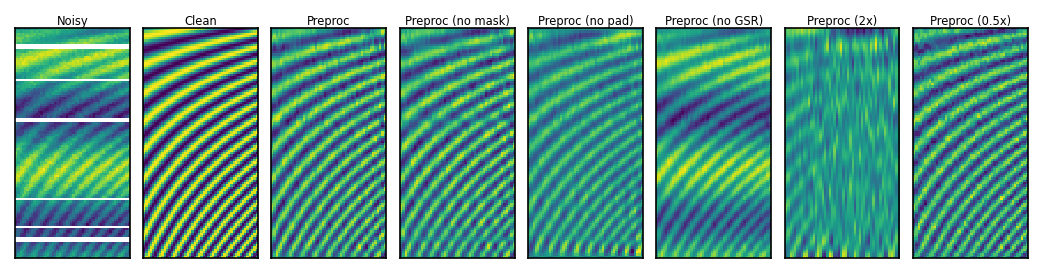

In [6]:
nr = 1
nc = 8
plotw = 2 * PLOTW / nc
ploth = (n_samples / n_features) * plotw

f, axs = plt.subplots(nr, nc, figsize=(plotw * nc, ploth * nr), layout="constrained")

all_series = [
    raw,
    series,
    proc_full,
    proc_nomask,
    proc_nopad,
    proc_nogsr,
    proc_fast,
    proc_slow,
]

titles = [
    "Noisy",
    "Clean",
    "Preproc",
    "Preproc (no mask)",
    "Preproc (no pad)",
    "Preproc (no GSR)",
    "Preproc (2x)",
    "Preproc (0.5x)",
]

for ii, (data, title) in enumerate(zip(all_series, titles)):
    plt.sca(axs[ii])
    plt.imshow(data, interpolation="nearest")
    plt.xticks([])
    plt.yticks([])
    plt.title(title, fontsize="x-small", pad=2)

plt.savefig(ts_preproc_dir / f"synthetic_timeseries_preprocessing.{FORMAT}")